## NEW CODE

In [471]:
import pandas as pd
import numpy as np
from geopy.distance import geodesic
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.model_selection import train_test_split

# Load your dataset
# Assuming your data is in a CSV file
df = pd.read_csv('training_dataset.csv')

# Convert 'timestamp' to datetime
df['timestamp'] = pd.to_datetime(df['timestamp'])

# Sort the DataFrame by 'user_id' and 'timestamp'
df = df.sort_values(by=['user_id', 'timestamp'])

In [472]:
df.columns

Index(['transaction_id', 'user_id', 'merchant_id', 'device_id', 'ip_address',
       'browser_fingerprint', 'currency', 'transaction_type', 'status',
       'balance_before', 'timestamp', 'amount', 'merchant_category',
       'geolocation', 'is_fraudulent', 'is_new_device', 'risk_score',
       'transaction_velocity', 'geo_velocity'],
      dtype='object')

In [473]:

# Step 1: User Behavior Features

# 1.1 Transaction Velocity (number of transactions in the last hour)
df['transaction_velocity'] = (
    df.groupby('user_id', group_keys=False)
    .apply(lambda x: x.sort_values('timestamp').set_index('timestamp')['amount'].rolling('1H').count())
    .reset_index(level=0, drop=True)
)

# 1.2 Average Transaction Amount (over the last 7 days)
df['avg_transaction_amount'] = (
    df.groupby('user_id', group_keys=False)
    .apply(lambda x: x.sort_values('timestamp').set_index('timestamp')['amount'].rolling('7D').mean())
    .reset_index(level=0, drop=True)
)

# 1.3 Typical Merchant Category (most frequent category for the user)
df['typical_merchant_category'] = df.groupby('user_id')['merchant_category'].transform(lambda x: x.mode()[0])

# 1.4 Time Since Last Transaction (in seconds)
df['time_since_last_transaction'] = df.groupby('user_id')['timestamp'].diff().dt.total_seconds()

# Step 2: Device Behavior Features

# 2.1 Device Frequency (number of transactions from this device in the last 7 days)
df['device_frequency'] = (
    df.groupby('device_id', group_keys=False)
    .apply(lambda x: x.sort_values('timestamp').set_index('timestamp')['amount'].rolling('7D').count())
    .reset_index(level=0, drop=True)
)

# Display the processed DataFrame
# print(df.head())


/var/folders/9b/p02j0s991xl5svg4nyn2wnpc0000gn/T/ipykernel_1007/4218242309.py:6: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  .apply(lambda x: x.sort_values('timestamp').set_index('timestamp')['amount'].rolling('1H').count())
/var/folders/9b/p02j0s991xl5svg4nyn2wnpc0000gn/T/ipykernel_1007/4218242309.py:6: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  .apply(lambda x: x.sort_values('timestamp').set_index('timestamp')['amount'].rolling('1H').count())
/var/folders/9b/p02j0s991xl5svg4nyn2wnpc0000gn/T/ipykernel_1007/4218242309.py:6: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  .apply(lambda x: x.sort_values('timestamp').set_index('timestamp')['amount'].rolling('1H').count())
/var/folders/9b/p02j0s991xl5svg4nyn2wnpc0000gn/T/ipykernel_1007/4218242309.py:6: FutureWarning: 'H' is deprecated and will be removed in a future version, pl

In [474]:
df['rolling_avg_amount'] = df.groupby('user_id')['amount'].rolling(window=7, min_periods=1).mean().reset_index(0, drop=True)
df['transactions_per_hour'] = df.groupby('user_id')['timestamp'].transform(lambda x: x.diff().dt.total_seconds().count() / 3600)

In [422]:
df.head()

,transaction_id,user_id,merchant_id,device_id,ip_address,browser_fingerprint,currency,transaction_type,status,balance_before,...,is_new_device,risk_score,transaction_velocity,geo_velocity,avg_transaction_amount,typical_merchant_category,time_since_last_transaction,device_frequency,rolling_avg_amount,transactions_per_hour
115278,TXN1116279,U001,M615,D684,25.183.196.73,1d0012839f79c2a9e63b867616da83f43c1c10a6d12ed4...,USD,Purchase,Success,4012.626014,...,False,0.19,1.0,-0.74,1674.274822,Luxury Goods,NaN,7.0,28.770000,0.123889
124357,TXN1125358,U001,M633,D662,192.174.51.113,5e9c3002c2e2da9c188e28f97e81b01257f579aeee88b1...,USD,Transfer,Success,6291.315073,...,False,0.20,2.0,-0.39,467.189198,Luxury Goods,29071.136126,16.0,100.370000,0.123889
399544,TXN1400545,U001,M828,D256,150.228.137.179,94767fc90172381e6916c72a2760927fd97d438a268f44...,USD,Purchase,Pending,6499.388271,...,True,0.71,1.0,-0.47,624.681118,Luxury Goods,67053.511952,14.0,1800.083539,0.123889
51214,TXN1052215,U001,M085,D146,178.167.69.148,7b382eabb21b3d62ab7c42ebb7338349aab9c8ec8816ed...,USD,Purchase,Success,5406.778236,...,False,0.20,1.0,-0.68,1608.646504,Luxury Goods,341795.302075,12.0,1402.242654,0.123889
291948,TXN1292949,U001,M726,D171,95.226.176.213,66e3f1d263c77306e310de742f202c16562a1a89a686c5...,USD,Purchase,Pending,9463.273037,...,True,0.71,1.0,-3.08,1011.332340,Luxury Goods,4544.104323,7.0,2635.917809,0.123889


In [475]:
# Step 3: Geolocation Features
# 3.1 Distance from Last Transaction (using geolocation)
def calculate_distance(row):
    if pd.isna(row['prev_lat']) or pd.isna(row['prev_lon']):
        return 0
    prev_coords = (row['prev_lat'], row['prev_lon'])
    curr_coords = (row['lat'], row['lon'])
    return geodesic(prev_coords, curr_coords).km

# Extract latitude and longitude from geolocation
df[['lat', 'lon']] = df['geolocation'].str.extract(r'([\d.-]+)° [NS], ([\d.-]+)° [EW]').astype(float)

# Calculate previous latitude and longitude
df['prev_lat'] = df.groupby('user_id')['lat'].shift(1)
df['prev_lon'] = df.groupby('user_id')['lon'].shift(1)

# Calculate distance from last transaction
df['distance_from_last_transaction'] = df.apply(calculate_distance, axis=1)

In [476]:
# # 3.2 Geo Velocity (distance/time since last transaction)
df['geo_velocity'] = df['distance_from_last_transaction'] / (df['time_since_last_transaction'] / 3600)  # km/h

# # Step 4: Time-Based Features
# 4.1 Hour of Day
df['hour_of_day'] = df['timestamp'].dt.hour

# 4.2 Day of Week
df['day_of_week'] = df['timestamp'].dt.dayofweek

In [425]:
df.columns

Index(['transaction_id', 'user_id', 'merchant_id', 'device_id', 'ip_address',
       'browser_fingerprint', 'currency', 'transaction_type', 'status',
       'balance_before', 'timestamp', 'amount', 'merchant_category',
       'geolocation', 'is_fraudulent', 'is_new_device', 'risk_score',
       'transaction_velocity', 'geo_velocity', 'avg_transaction_amount',
       'typical_merchant_category', 'time_since_last_transaction',
       'device_frequency', 'rolling_avg_amount', 'transactions_per_hour',
       'lat', 'lon', 'prev_lat', 'prev_lon', 'distance_from_last_transaction',
       'hour_of_day', 'day_of_week'],
      dtype='object')

In [426]:
df.head()

,transaction_id,user_id,merchant_id,device_id,ip_address,browser_fingerprint,currency,transaction_type,status,balance_before,...,device_frequency,rolling_avg_amount,transactions_per_hour,lat,lon,prev_lat,prev_lon,distance_from_last_transaction,hour_of_day,day_of_week
115278,TXN1116279,U001,M615,D684,25.183.196.73,1d0012839f79c2a9e63b867616da83f43c1c10a6d12ed4...,USD,Purchase,Success,4012.626014,...,7.0,28.770000,0.123889,26.0673,-105.5360,NaN,NaN,0.000000,23,1
124357,TXN1125358,U001,M633,D662,192.174.51.113,5e9c3002c2e2da9c188e28f97e81b01257f579aeee88b1...,USD,Transfer,Success,6291.315073,...,16.0,100.370000,0.123889,30.7221,-102.3042,26.0673,-105.5360,605.250151,7,2
399544,TXN1400545,U001,M828,D256,150.228.137.179,94767fc90172381e6916c72a2760927fd97d438a268f44...,USD,Purchase,Pending,6499.388271,...,14.0,1800.083539,0.123889,50.5698,108.3969,30.7221,-102.3042,10507.993249,1,3
51214,TXN1052215,U001,M085,D146,178.167.69.148,7b382eabb21b3d62ab7c42ebb7338349aab9c8ec8816ed...,USD,Purchase,Success,5406.778236,...,12.0,1402.242654,0.123889,43.4197,-116.4979,50.5698,108.3969,8722.473755,0,0
291948,TXN1292949,U001,M726,D171,95.226.176.213,66e3f1d263c77306e310de742f202c16562a1a89a686c5...,USD,Purchase,Pending,9463.273037,...,7.0,2635.917809,0.123889,46.6838,123.4446,43.4197,-116.4979,8417.264495,1,0


In [477]:
# 🔹 Step 1: Count how many times a fingerprint appears
df['browser_fp_count'] = df.groupby('browser_fingerprint')['browser_fingerprint'].transform('count')

# 🔹 Step 2: Count unique fingerprints per user
df['unique_fp_per_user'] = df.groupby('user_id')['browser_fingerprint'].transform('nunique')

# 🔹 Step 3: Calculate fingerprint ratio per user
df['browser_fp_user_ratio'] = df['browser_fp_count'] / df['unique_fp_per_user']

# 🔹 Step 4: Identify if the fingerprint is new for this user
# df['is_new_fingerprint'] = df.groupby('user_id')['browser_fingerprint'].transform(lambda x: x.duplicated(keep='first')).astype(int)


In [478]:
from sklearn.preprocessing import LabelEncoder
# 🔹 Step 5: Encode the browser fingerprint as categorical features
df['browser_fingerprint_encoded'] = LabelEncoder().fit_transform(df['browser_fingerprint'])

In [429]:
df.head()

,transaction_id,user_id,merchant_id,device_id,ip_address,browser_fingerprint,currency,transaction_type,status,balance_before,...,lon,prev_lat,prev_lon,distance_from_last_transaction,hour_of_day,day_of_week,browser_fp_count,unique_fp_per_user,browser_fp_user_ratio,browser_fingerprint_encoded
115278,TXN1116279,U001,M615,D684,25.183.196.73,1d0012839f79c2a9e63b867616da83f43c1c10a6d12ed4...,USD,Purchase,Success,4012.626014,...,-105.5360,NaN,NaN,0.000000,23,1,1,447,0.002237,56714
124357,TXN1125358,U001,M633,D662,192.174.51.113,5e9c3002c2e2da9c188e28f97e81b01257f579aeee88b1...,USD,Transfer,Success,6291.315073,...,-102.3042,26.0673,-105.5360,605.250151,7,2,1,447,0.002237,184884
399544,TXN1400545,U001,M828,D256,150.228.137.179,94767fc90172381e6916c72a2760927fd97d438a268f44...,USD,Purchase,Pending,6499.388271,...,108.3969,30.7221,-102.3042,10507.993249,1,3,1,447,0.002237,289602
51214,TXN1052215,U001,M085,D146,178.167.69.148,7b382eabb21b3d62ab7c42ebb7338349aab9c8ec8816ed...,USD,Purchase,Success,5406.778236,...,-116.4979,50.5698,108.3969,8722.473755,0,0,1,447,0.002237,240575
291948,TXN1292949,U001,M726,D171,95.226.176.213,66e3f1d263c77306e310de742f202c16562a1a89a686c5...,USD,Purchase,Pending,9463.273037,...,123.4446,43.4197,-116.4979,8417.264495,1,0,1,447,0.002237,201109


In [430]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 500000 entries, 115278 to 308048
Data columns (total 36 columns):
 #   Column                          Non-Null Count   Dtype         
---  ------                          --------------   -----         
 0   transaction_id                  500000 non-null  object        
 1   user_id                         500000 non-null  object        
 2   merchant_id                     500000 non-null  object        
 3   device_id                       500000 non-null  object        
 4   ip_address                      500000 non-null  object        
 5   browser_fingerprint             500000 non-null  object        
 6   currency                        500000 non-null  object        
 7   transaction_type                500000 non-null  object        
 8   status                          500000 non-null  object        
 9   balance_before                  500000 non-null  float64       
 10  timestamp                       500000 non-null  datetim

In [246]:
'balance_before', 'time_since_last_transaction', 'device_frequency', 'lat', 'lon', 'prev_lat', 'prev_lon', 'distance_from_last_transaction', 'transaction_ratio'

('balance_before',
 'time_since_last_transaction',
 'device_frequency',
 'lat',
 'lon',
 'prev_lat',
 'prev_lon',
 'distance_from_last_transaction',
 'transaction_ratio')

In [479]:
df.dropna(inplace=True)
df.drop_duplicates(inplace=True)

In [480]:

merchant_category = {"Groceries" : 0,  'Bank' : 1, 'Electronics' : 2,  'ATM' : 3, 'Restaurant' : 4, 'Luxury Goods' : 5}
    # status = {'Success' : 0, 'Pending' : 1}


df['merchant_category'] = df['merchant_category'].map(merchant_category)
status = {'Success' : 0, 'Pending' : 1, 'Failed' : 2}
df['status'] = df['status'].map(status)
transaction_type = {'Refund' : 0, 'Transfer' : 1, 'Purchase' : 2, 'Withdrawal' : 3}

df['transaction_type'] = df['transaction_type'].map(transaction_type)
df['transaction_ratio'] = df['amount'] / df['balance_before']
df['is_new_device'] = df['is_new_device'].astype(int)


In [378]:
df.columns

Index(['transaction_id', 'user_id', 'merchant_id', 'device_id', 'ip_address',
       'browser_fingerprint', 'currency', 'transaction_type', 'status',
       'balance_before', 'timestamp', 'amount', 'merchant_category',
       'geolocation', 'is_fraudulent', 'is_new_device', 'risk_score',
       'transaction_velocity', 'geo_velocity', 'avg_transaction_amount',
       'typical_merchant_category', 'time_since_last_transaction',
       'device_frequency', 'rolling_avg_amount', 'transactions_per_hour',
       'lat', 'lon', 'prev_lat', 'prev_lon', 'distance_from_last_transaction',
       'hour_of_day', 'day_of_week', 'unique_fp_per_user', 'browser_fp_count',
       'browser_fp_user_ratio', 'browser_fingerprint_encoded',
       'transaction_ratio'],
      dtype='object')

In [463]:
from sklearn.preprocessing import MinMaxScaler
scaler = MinMaxScaler()
df['amount'] = np.log1p(df['amount'])
columns_to_normalize = ['balance_before', 'device_frequency','transaction_ratio','browser_fp_count','unique_fp_per_user','browser_fp_user_ratio','browser_fingerprint_encoded','transaction_velocity']
df[columns_to_normalize] = scaler.fit_transform(df[columns_to_normalize])

In [464]:
df.columns

Index(['transaction_id', 'user_id', 'merchant_id', 'device_id', 'ip_address',
       'browser_fingerprint', 'currency', 'transaction_type', 'status',
       'balance_before', 'timestamp', 'amount', 'merchant_category',
       'geolocation', 'is_fraudulent', 'is_new_device', 'risk_score',
       'transaction_velocity', 'geo_velocity', 'avg_transaction_amount',
       'typical_merchant_category', 'time_since_last_transaction',
       'device_frequency', 'rolling_avg_amount', 'transactions_per_hour',
       'lat', 'lon', 'prev_lat', 'prev_lon', 'distance_from_last_transaction',
       'hour_of_day', 'day_of_week', 'browser_fp_count', 'unique_fp_per_user',
       'browser_fp_user_ratio', 'browser_fingerprint_encoded',
       'transaction_ratio'],
      dtype='object')

In [465]:
df.head()

,transaction_id,user_id,merchant_id,device_id,ip_address,browser_fingerprint,currency,transaction_type,status,balance_before,...,prev_lat,prev_lon,distance_from_last_transaction,hour_of_day,day_of_week,browser_fp_count,unique_fp_per_user,browser_fp_user_ratio,browser_fingerprint_encoded,transaction_ratio
124357,TXN1125358,U001,M633,D662,192.174.51.113,5e9c3002c2e2da9c188e28f97e81b01257f579aeee88b1...,USD,1,0,0.587240,...,26.0673,-105.5360,605.250151,7,2,0.0,0.106383,0.86363,0.369769,0.014995
399544,TXN1400545,U001,M828,D256,150.228.137.179,94767fc90172381e6916c72a2760927fd97d438a268f44...,USD,2,1,0.610398,...,30.7221,-102.3042,10507.993249,1,3,0.0,0.106383,0.86363,0.579205,0.440214
51214,TXN1052215,U001,M085,D146,178.167.69.148,7b382eabb21b3d62ab7c42ebb7338349aab9c8ec8816ed...,USD,2,0,0.488789,...,50.5698,108.3969,8722.473755,0,0,0.0,0.106383,0.86363,0.481151,0.021197
291948,TXN1292949,U001,M726,D171,95.226.176.213,66e3f1d263c77306e310de742f202c16562a1a89a686c5...,USD,2,1,0.940285,...,43.4197,-116.4979,8417.264495,1,0,0.0,0.106383,0.86363,0.402219,0.440214
353636,TXN1354637,U001,M418,D440,146.14.44.227,9041dddddbb1c80c1b2fbc27eb2d7d7d058c09c82e3a7b...,USD,2,1,0.325713,...,46.6838,123.4446,3503.434863,3,0,0.0,0.106383,0.86363,0.562773,0.440214


In [466]:
df.columns

Index(['transaction_id', 'user_id', 'merchant_id', 'device_id', 'ip_address',
       'browser_fingerprint', 'currency', 'transaction_type', 'status',
       'balance_before', 'timestamp', 'amount', 'merchant_category',
       'geolocation', 'is_fraudulent', 'is_new_device', 'risk_score',
       'transaction_velocity', 'geo_velocity', 'avg_transaction_amount',
       'typical_merchant_category', 'time_since_last_transaction',
       'device_frequency', 'rolling_avg_amount', 'transactions_per_hour',
       'lat', 'lon', 'prev_lat', 'prev_lon', 'distance_from_last_transaction',
       'hour_of_day', 'day_of_week', 'browser_fp_count', 'unique_fp_per_user',
       'browser_fp_user_ratio', 'browser_fingerprint_encoded',
       'transaction_ratio'],
      dtype='object')

In [434]:
import seaborn as sns
import matplotlib.pyplot as plt

def box_plot(col_name):
    plt.figure(figsize=(8, 5))
    sns.boxplot(x=df[col_name])
    plt.title(f"Boxplot of {col_name} (Outlier Detection)")
    plt.show()


In [ ]:
df.columns

Index(['transaction_type', 'amount', 'merchant_category', 'is_fraudulent',
       'transaction_velocity', 'geo_velocity', 'avg_transaction_amount',
       'rolling_avg_amount', 'transactions_per_hour', 'lat', 'lon', 'prev_lat',
       'prev_lon', 'distance_from_last_transaction', 'hour_of_day',
       'day_of_week', 'unique_fp_per_user', 'browser_fp_user_ratio',
       'browser_fingerprint_encoded'],
      dtype='object')

In [344]:
df.columns

Index(['transaction_id', 'user_id', 'merchant_id', 'device_id', 'ip_address',
       'browser_fingerprint', 'currency', 'transaction_type', 'status',
       'balance_before', 'timestamp', 'amount', 'merchant_category',
       'geolocation', 'is_fraudulent', 'is_new_device', 'risk_score',
       'transaction_velocity', 'geo_velocity', 'avg_transaction_amount',
       'typical_merchant_category', 'time_since_last_transaction',
       'device_frequency', 'rolling_avg_amount', 'transactions_per_hour',
       'lat', 'lon', 'prev_lat', 'prev_lon', 'distance_from_last_transaction',
       'hour_of_day', 'day_of_week', 'browser_fp_count', 'unique_fp_per_user',
       'browser_fp_user_ratio', 'is_new_fingerprint',
       'browser_fingerprint_encoded', 'transaction_ratio'],
      dtype='object')

In [481]:
clean_df = df.drop(['transaction_id', 'user_id', 'merchant_id', 'device_id', 'ip_address','geolocation',
       'browser_fingerprint', 'currency',  'status', 'is_new_device','risk_score', 'typical_merchant_category'], axis=1)


In [468]:
clean_df.columns

Index(['transaction_type', 'balance_before', 'timestamp', 'amount',
       'merchant_category', 'is_fraudulent', 'transaction_velocity',
       'geo_velocity', 'avg_transaction_amount', 'time_since_last_transaction',
       'device_frequency', 'rolling_avg_amount', 'transactions_per_hour',
       'lat', 'lon', 'prev_lat', 'prev_lon', 'distance_from_last_transaction',
       'hour_of_day', 'day_of_week', 'browser_fp_count', 'unique_fp_per_user',
       'browser_fp_user_ratio', 'browser_fingerprint_encoded',
       'transaction_ratio'],
      dtype='object')

In [482]:
import pandas as pd

# Assuming your DataFrame is named df
correlation_matrix = clean_df.corr()

# Extract correlation with 'is_fraudulent'
correlation_with_target = correlation_matrix['is_fraudulent'].abs().sort_values(ascending=False)

print(correlation_with_target)

is_fraudulent                     1.000000e+00
lon                               9.850104e-01
merchant_category                 8.426375e-01
transaction_ratio                 5.776644e-01
amount                            5.119376e-01
hour_of_day                       3.108006e-01
transaction_type                  3.016737e-01
rolling_avg_amount                1.939408e-01
lat                               2.831460e-02
distance_from_last_transaction    1.816851e-02
time_since_last_transaction       6.942701e-03
prev_lon                          3.363524e-03
browser_fp_user_ratio             1.606782e-03
transactions_per_hour             1.488111e-03
unique_fp_per_user                1.488111e-03
balance_before                    1.436620e-03
geo_velocity                      1.385449e-03
transaction_velocity              9.661789e-04
timestamp                         8.118549e-04
avg_transaction_amount            5.579885e-04
device_frequency                  4.487283e-04
browser_finge

In [483]:
correlation_with_target.fillna(0, inplace=True)

In [ ]:
# clean_df.drop(['is_new_fingerprint', 'browser_fp_count'], axis=1, inplace=True)

In [394]:
clean_df.columns

Index(['transaction_type', 'amount', 'merchant_category', 'is_fraudulent',
       'rolling_avg_amount', 'lon', 'hour_of_day', 'browser_fp_count',
       'transaction_ratio'],
      dtype='object')

In [484]:
# Assuming you want to drop columns with correlation < 0.1
columns_to_drop = correlation_with_target[correlation_with_target < 0.1].index

# Drop these columns from the DataFrame
clean_df.drop(columns=columns_to_drop, axis=1, inplace=True)

print("Columns dropped:", columns_to_drop)
print("Remaining columns:", clean_df.columns)

Columns dropped: Index(['lat', 'distance_from_last_transaction', 'time_since_last_transaction',
       'prev_lon', 'browser_fp_user_ratio', 'transactions_per_hour',
       'unique_fp_per_user', 'balance_before', 'geo_velocity',
       'transaction_velocity', 'timestamp', 'avg_transaction_amount',
       'device_frequency', 'browser_fingerprint_encoded', 'prev_lat',
       'day_of_week', 'browser_fp_count'],
      dtype='object')
Remaining columns: Index(['transaction_type', 'amount', 'merchant_category', 'is_fraudulent',
       'rolling_avg_amount', 'lon', 'hour_of_day', 'transaction_ratio'],
      dtype='object')


In [439]:
clean_df.columns

Index(['transaction_type', 'amount', 'merchant_category', 'is_fraudulent',
       'rolling_avg_amount', 'lon', 'hour_of_day', 'transaction_ratio'],
      dtype='object')

In [485]:
clean_df.to_csv('clean_data_pre.csv', index=False)

In [457]:
from sklearn.model_selection import train_test_split
import pandas as pd
def split_data(df_clean):

    Y = df_clean['is_fraudulent']
    X = df_clean.drop(columns=['is_fraudulent'], axis=1)   
    X_train, X_test, y_train, y_test = train_test_split(X, Y, test_size=0.1, random_state=42, stratify=Y)

    # Print dataset sizes
    print(f"Training Set: {X_train.shape[0]} rows")
    print(f"Testing Set: {X_test.shape[0]} rows")  

    return X_train, X_test, y_train, y_test 
X_train, X_test, y_train, y_test = split_data(clean_df)
print(f"X_train : {X_train.shape}")
print(f"X_test : {X_test.shape}")
print(f"y_train : {y_train.shape}")
print(f"y_test : {y_test.shape}")

Training Set: 449100 rows
Testing Set: 49901 rows
X_train : (449100, 7)
X_test : (49901, 7)
y_train : (449100,)
y_test : (49901,)


In [458]:
X_train.columns

Index(['transaction_type', 'amount', 'merchant_category', 'rolling_avg_amount',
       'lon', 'hour_of_day', 'transaction_ratio'],
      dtype='object')

In [453]:
clean_df.columns

Index(['transaction_type', 'amount', 'merchant_category', 'is_fraudulent',
       'rolling_avg_amount', 'lon', 'hour_of_day', 'transaction_ratio'],
      dtype='object')

Index(['transaction_type', 'amount', 'merchant_category', 'is_fraudulent',
       'transaction_velocity', 'hour', 'lon', 'transaction_ratio'],
      dtype='object')

In [441]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.regularizers import l2
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping

# Define the improved ANN model
def build_ann():
    model = keras.Sequential([
        layers.Dense(128, activation='relu', kernel_regularizer=l2(0.001), input_shape=(X_train.shape[1],)), 
        layers.BatchNormalization(),
        layers.Dropout(0.4),

        layers.Dense(64, activation='relu', kernel_regularizer=l2(0.001)),
        layers.BatchNormalization(),
        layers.Dropout(0.4),

        layers.Dense(32, activation='relu', kernel_regularizer=l2(0.001)),
        layers.BatchNormalization(),
        layers.Dropout(0.4),

        layers.Dense(16, activation='relu', kernel_regularizer=l2(0.001)),
        layers.BatchNormalization(),
        layers.Dropout(0.3),

        layers.Dense(1, activation='sigmoid')  # Output layer for binary classification
    ])
    
    # Compile model
    model.compile(optimizer=Adam(learning_rate=0.0005), loss='binary_crossentropy', metrics=['accuracy'])
    return model

# Instantiate the model
model_l1_l2 = build_ann()

# Add Early Stopping to prevent overfitting
early_stopping = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)

# Train the model
history_l1_l2 = model_l1_l2.fit(X_train, y_train, epochs=10, batch_size=32, validation_split=0.2, shuffle=True, callbacks=[early_stopping])


Epoch 1/10


/Users/UZAIR/Desktop/fraud_detection/venv/lib/python3.12/site-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


11228/11228 ━━━━━━━━━━━━━━━━━━━━ 28s 2ms/step - accuracy: 0.9723 - loss: 0.1594 - val_accuracy: 1.0000 - val_loss: 0.0086
Epoch 2/10
11228/11228 ━━━━━━━━━━━━━━━━━━━━ 33s 3ms/step - accuracy: 0.9992 - loss: 0.0106 - val_accuracy: 1.0000 - val_loss: 0.0051
Epoch 3/10
11228/11228 ━━━━━━━━━━━━━━━━━━━━ 30s 3ms/step - accuracy: 0.9994 - loss: 0.0075 - val_accuracy: 1.0000 - val_loss: 0.0042
Epoch 4/10
11228/11228 ━━━━━━━━━━━━━━━━━━━━ 30s 3ms/step - accuracy: 0.9995 - loss: 0.0063 - val_accuracy: 1.0000 - val_loss: 0.0035
Epoch 5/10
11228/11228 ━━━━━━━━━━━━━━━━━━━━ 30s 3ms/step - accuracy: 0.9998 - loss: 0.0046 - val_accuracy: 1.0000 - val_loss: 0.0038
Epoch 6/10
11228/11228 ━━━━━━━━━━━━━━━━━━━━ 31s 3ms/step - accuracy: 0.9996 - loss: 0.0050 - val_accuracy: 1.0000 - val_loss: 0.0034
Epoch 7/10
11228/11228 ━━━━━━━━━━━━━━━━━━━━ 32s 3ms/step - accuracy: 0.9997 - loss: 0.0044 - val_accuracy: 1.0000 - val_loss: 0.0034
Epoch 8/10
11228/11228 ━━━━━━━━━━━━━━━━━━━━ 33s 3ms/step - accuracy: 0.9997 - lo

In [265]:
model_l1_l2.save('pre_training.h5')

In [442]:
# Evaluate on test data
test_loss, test_acc = model_l1_l2.evaluate(X_test, y_test, verbose=1)
print(f"\nTest Accuracy: {test_acc:.4f}")
print(f"\nTest Loss: {test_loss:.9f}")


1560/1560 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 1.0000 - loss: 0.0026

Test Accuracy: 1.0000

Test Loss: 0.002607594


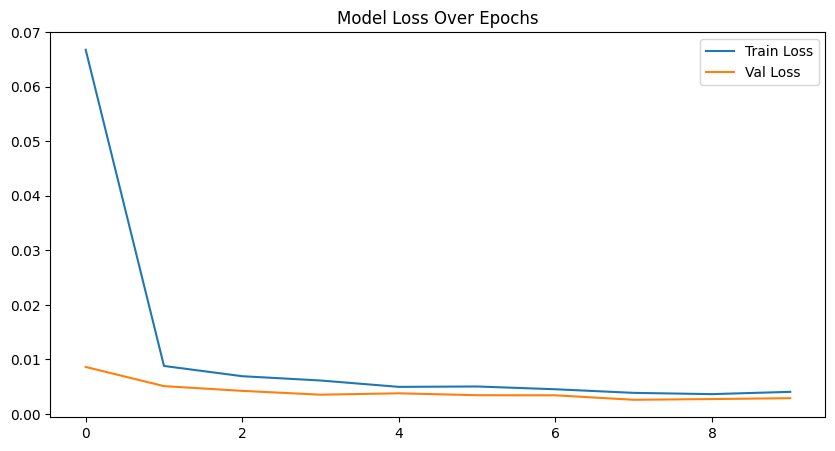

In [443]:
import matplotlib.pyplot as plt
# Plot training history
plt.figure(figsize=(10, 5))
plt.plot(history_l1_l2.history['loss'], label='Train Loss')
plt.plot(history_l1_l2.history['val_loss'], label='Val Loss')
plt.legend()
plt.title('Model Loss Over Epochs')
plt.show()

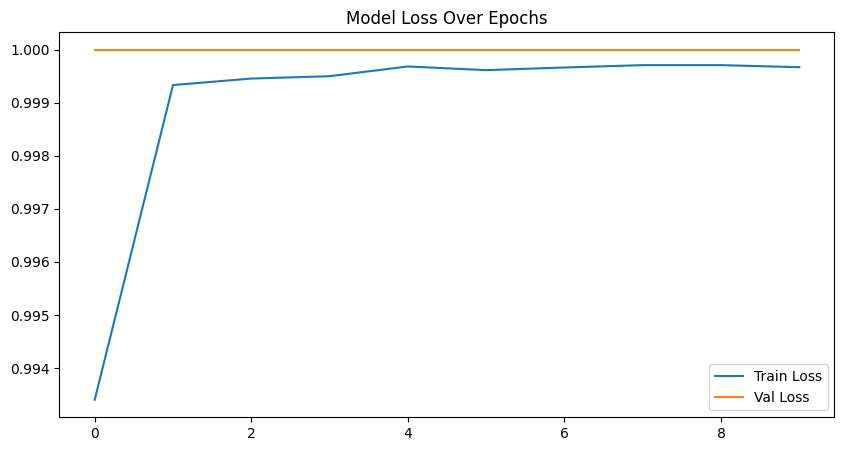

In [444]:

# Plot training history
plt.figure(figsize=(10, 5))
plt.plot(history_l1_l2.history['accuracy'], label='Train Loss')
plt.plot(history_l1_l2.history['val_accuracy'], label='Val Loss')
plt.legend()
plt.title('Model Loss Over Epochs')
plt.show()

In [445]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.regularizers import l2
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping

# Define the improved ANN model
def build_ann():
    model = keras.Sequential([
        layers.Dense(64, activation='relu', kernel_regularizer=l2(0.001), input_shape=(X_train.shape[1],)), 
        layers.BatchNormalization(),
        layers.Dropout(0.5),

        layers.Dense(32, activation='relu', kernel_regularizer=l2(0.001)),
        layers.BatchNormalization(),
        layers.Dropout(0.5),

        layers.Dense(16, activation='relu', kernel_regularizer=l2(0.001)),
        layers.BatchNormalization(),
        layers.Dropout(0.4),

        layers.Dense(1, activation='sigmoid')  # Output layer for binary classification
    ])
    
    # Compile model
    model.compile(optimizer=Adam(learning_rate=0.0005), loss='binary_crossentropy', metrics=['accuracy'])
    return model

# Instantiate the model
model_l2_5d = build_ann()

# Add Early Stopping to prevent overfitting
early_stopping = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)

# Train the model
history_l2_5d = model_l2_5d.fit(X_train, y_train, epochs=10, batch_size=64, validation_split=0.2, shuffle=True, callbacks=[early_stopping])


Epoch 1/10


/Users/UZAIR/Desktop/fraud_detection/venv/lib/python3.12/site-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


5614/5614 ━━━━━━━━━━━━━━━━━━━━ 16s 2ms/step - accuracy: 0.9459 - loss: 0.1813 - val_accuracy: 1.0000 - val_loss: 0.0051
Epoch 2/10
5614/5614 ━━━━━━━━━━━━━━━━━━━━ 17s 3ms/step - accuracy: 0.9996 - loss: 0.0048 - val_accuracy: 1.0000 - val_loss: 0.0012
Epoch 3/10
5614/5614 ━━━━━━━━━━━━━━━━━━━━ 17s 3ms/step - accuracy: 0.9998 - loss: 0.0018 - val_accuracy: 1.0000 - val_loss: 7.7855e-04
Epoch 4/10
5614/5614 ━━━━━━━━━━━━━━━━━━━━ 13s 2ms/step - accuracy: 0.9996 - loss: 0.0022 - val_accuracy: 1.0000 - val_loss: 7.0120e-04
Epoch 5/10
5614/5614 ━━━━━━━━━━━━━━━━━━━━ 13s 2ms/step - accuracy: 0.9998 - loss: 0.0016 - val_accuracy: 1.0000 - val_loss: 7.7188e-04
Epoch 6/10
5614/5614 ━━━━━━━━━━━━━━━━━━━━ 12s 2ms/step - accuracy: 0.9995 - loss: 0.0024 - val_accuracy: 1.0000 - val_loss: 0.0011
Epoch 7/10
5614/5614 ━━━━━━━━━━━━━━━━━━━━ 12s 2ms/step - accuracy: 0.9998 - loss: 0.0017 - val_accuracy: 1.0000 - val_loss: 8.9291e-04
Epoch 8/10
5614/5614 ━━━━━━━━━━━━━━━━━━━━ 13s 2ms/step - accuracy: 0.9997 - lo

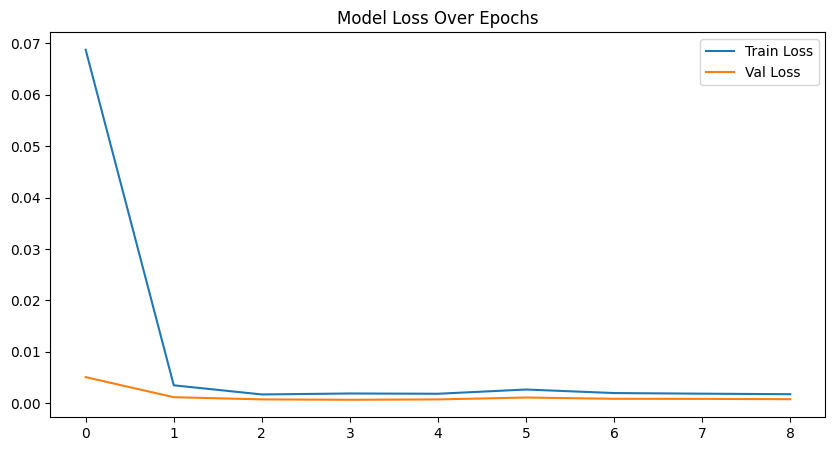

In [446]:
import matplotlib.pyplot as plt
# Plot training history
plt.figure(figsize=(10, 5))
plt.plot(history_l2_5d.history['loss'], label='Train Loss')
plt.plot(history_l2_5d.history['val_loss'], label='Val Loss')
plt.legend()
plt.title('Model Loss Over Epochs')
plt.show()

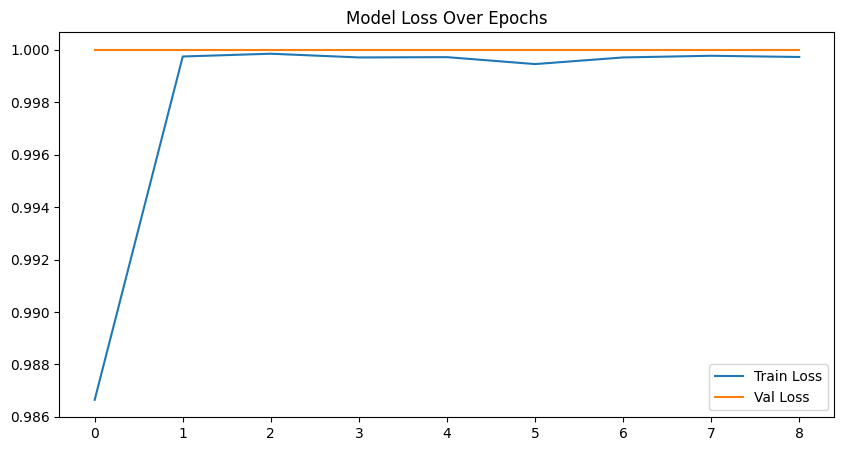

In [447]:
import matplotlib.pyplot as plt
# Plot training history
plt.figure(figsize=(10, 5))
plt.plot(history_l2_5d.history['accuracy'], label='Train Loss')
plt.plot(history_l2_5d.history['val_accuracy'], label='Val Loss')
plt.legend()
plt.title('Model Loss Over Epochs')
plt.show()

In [448]:
# Evaluate on test data
test_loss, test_acc = model_l2_5d.evaluate(X_test, y_test, verbose=1)
print(f"\nTest Accuracy: {test_acc:.4f}")
print(f"\nTest Loss: {test_loss:.9f}")

1560/1560 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 1.0000 - loss: 7.0121e-04

Test Accuracy: 1.0000

Test Loss: 0.000701200


In [ ]:
import numpy as np
import pandas as pd
import shap

# import lime.lime_tabular

from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()

def predict_fraud(values, model):
    merchant_category = {"groceries": 0, "bank": 1, "electronics": 2, "atm": 3, "restaurant": 4, "luxury goods": 5}
    values['merchant_category'] = merchant_category[values['merchant_category']]
    values['amount'] = np.log1p(values['amount'])

    new_transaction = pd.DataFrame([values])

    columns_to_normalize = ['amount', 'transaction_velocity', 'lon', 'transaction_ratio']
    new_transaction[columns_to_normalize] = scaler.fit_transform(new_transaction[columns_to_normalize])

    print("Prediction time....")
    fraud_probability = model.predict(new_transaction)[0][0]
    is_fraud = 1 if fraud_probability > 0.5 else 0

    print(f"Fraud Probability: {fraud_probability:.4f}")
    print(f"Is Fraudulent? {'Yes' if is_fraud else 'No'}")

    # **SHAP Explanation**
    explainer = shap.Explainer(model, new_transaction)
    shap_values = explainer(new_transaction)
    # Extracting specific values
    shap_values_array = shap_values.values
    base_values = shap_values.base_values
    data_values = shap_values.data

    features_importance = {"shap_values" : shap_values_array, "base_values" : base_values, "data_values" : data_values}
    print("SHAP Explanation:")
    print(features_importance)
    # shap.summary_plot(shap_values, new_transaction)

    return {"fraud_probability" : fraud_probability, "verdict" :  is_fraud, "features_importance" : features_importance}

new_data = {
        "transaction_type": 3,
        "amount": 145.75,  
        "merchant_category": 'groceries',
        "transaction_velocity": 500,  
        "hour": 12,  
        "lon": -102.4194,  
        "transaction_ratio": 0.15247458 
    }
response = predict_fraud(new_data, model_l2_5d)
print(response)

Prediction time....
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step
Fraud Probability: 1.0000
Is Fraudulent? Yes
SHAP Explanation:
{'shap_values': array([[0., 0., 0., 0., 0., 0., 0.]]), 'base_values': array([[0.99997228]]), 'data_values': array([[ 3.,  0.,  0.,  0., 12.,  0.,  0.]])}
{'fraud_probability': 0.9999723, 'verdict': 1, 'features_importance': {'shap_values': array([[0., 0., 0., 0., 0., 0., 0.]]), 'base_values': array([[0.99997228]]), 'data_values': array([[ 3.,  0.,  0.,  0., 12.,  0.,  0.]])}}


In [396]:
def generate_shap_description(shap_values, feature_names, base_value, prediction):
    description = f"The model predicts a {prediction * 100:.2f}% probability of fraud. Key factors contributing to this prediction are:"
    contributions = []
    for feature, value in zip(feature_names, shap_values):
        if value > 0:
            contributions.append(f"The {feature} increased the likelihood of fraud by {abs(value):.2f}.")
        else:
            contributions.append(f"The {feature} decreased the likelihood of fraud by {abs(value):.2f}.")
    return description, contributions

# Example usage
shap_values = [0.12, 0.45, -0.08, 0.23, -0.05]
feature_names = ['transaction_type', 'amount', 'merchant_category', 'transaction_velocity', 'hour']
base_value = -2.0
prediction = 0.85

description, contributions = generate_shap_description(shap_values, feature_names, base_value, prediction)

In [462]:
import numpy as np
import pandas as pd
import shap
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()

def generate_shap_description(shap_values, feature_names, base_value, prediction):
    description = f"The model predicts a {prediction * 100:.2f}% probability of fraud. Key factors contributing to this prediction are:"
    contributions = []
    
    for feature, value in zip(feature_names, shap_values):
        
        if value == 0.0:
            contributions.append(f"The {feature} dose not contributed the likelihood of fraud by {abs(value):.2f}.")
        elif value > 0:
            contributions.append(f"The {feature} increased the likelihood of fraud by {abs(value):.2f}.")
        
        else:
            contributions.append(f"The {feature} decreased the likelihood of fraud by {abs(value):.2f}.")
    
    return description, contributions

def predict_fraud(values, model):
    merchant_category = {"groceries": 0, "bank": 1, "electronics": 2, "atm": 3, "restaurant": 4, "luxury goods": 5}
    values['merchant_category'] = merchant_category[values['merchant_category']]
    values['amount'] = np.log1p(values['amount'])

    new_transaction = pd.DataFrame([values])

    columns_to_normalize = ['amount', 'transaction_velocity', 'lon', 'transaction_ratio']
    new_transaction[columns_to_normalize] = scaler.fit_transform(new_transaction[columns_to_normalize])

    print("Prediction time....")
    fraud_probability = model.predict(new_transaction)[0][0]
    is_fraud = 1 if fraud_probability > 0.5 else 0

    print(f"Fraud Probability: {fraud_probability:.4f}")
    print(f"Is Fraudulent? {'Yes' if is_fraud else 'No'}")

    # SHAP Explanation
    explainer = shap.Explainer(model, new_transaction)
    shap_values = explainer(new_transaction)
    
    # Extracting specific values
    shap_values_array = shap_values.values[0]
    base_value = shap_values.base_values[0]
    data_values = shap_values.data[0]
    feature_names = new_transaction.columns.tolist()
    
    features_importance = {
        "shap_values": shap_values_array.tolist(),
        "base_value": float(base_value),
        "data_values": data_values.tolist()
    }

    description, contributions = generate_shap_description(shap_values_array, feature_names, base_value, fraud_probability)

    print("SHAP Explanation:")
    print(description)
    # for contrib in contributions:
    #     print(contrib)

    return {
        "fraud_probability": fraud_probability,
        "verdict": is_fraud,
        "features_importance": features_importance,
        "shap_explanation": {
            "description": description,
            "contributions": contributions
        }
    }

# new_data = {
#     "transaction_type": 3,
#     "amount": 145.75,  
#     "merchant_category": "groceries",
#     "transaction_velocity": 500,  
#     "hour": 12,  
#     "lon": -102.4194,  
#     "transaction_ratio": 0.15247458 
# }

new_data = {'transaction_type': 3, 'amount': 145.75, 'merchant_category': 'groceries', 'transaction_velocity': 500.0, 'hour': 12, 'lon': -102.4194, 'transaction_ratio': 0.15247458}

print(len(new_data)+1)
print(len(['transaction_type', 'amount', 'merchant_category', 
       'rolling_avg_amount', 'lon', 'hour_of_day', 'transaction_ratio']))

response = predict_fraud(new_data, model_l2_5d)
print(response)


8
7
Prediction time....
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step
Fraud Probability: 1.0000
Is Fraudulent? Yes
SHAP Explanation:
The model predicts a 100.00% probability of fraud. Key factors contributing to this prediction are:
{'fraud_probability': 0.9999723, 'verdict': 1, 'features_importance': {'shap_values': [0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0], 'base_value': 0.9999722838401794, 'data_values': [3.0, 0.0, 0.0, 0.0, 12.0, 0.0, 0.0]}, 'shap_explanation': {'description': 'The model predicts a 100.00% probability of fraud. Key factors contributing to this prediction are:', 'contributions': ['The transaction_type dose not contributed the likelihood of fraud by 0.00.', 'The amount dose not contributed the likelihood of fraud by 0.00.', 'The merchant_category dose not contributed the likelihood of fraud by 0.00.', 'The transaction_velocity dose not contributed the likelihood of fraud by 0.00.', 'The hour dose not contributed the likelihood of fraud by 0.00.', 'The lon dose not contributed the 

/var/folders/9b/p02j0s991xl5svg4nyn2wnpc0000gn/T/ipykernel_1007/3926383454.py:53: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  "base_value": float(base_value),


In [450]:
model_l2_5d.save('backend_app/trained_model_weights/pre_training.h5')

In [408]:
from tensorflow.keras.models import load_model

ld_model = load_model("trained_model_weights/pre_training.keras")

/Users/UZAIR/Desktop/fraud_detection/venv/lib/python3.12/site-packages/keras/src/saving/saving_lib.py:757: UserWarning: Skipping variable loading for optimizer 'rmsprop', because it has 16 variables whereas the saved optimizer has 30 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))


In [411]:
new_data = {'transaction_type': 3, 'amount': 145.75, 'merchant_category': 'groceries', 'transaction_velocity': 500.0, 'hour': 12, 'lon': -102.4194, 'transaction_ratio': 0.15247458}

merchant_category = {"groceries": 0, "bank": 1, "electronics": 2, "atm": 3, "restaurant": 4, "luxury goods": 5}
new_data['merchant_category'] = merchant_category[new_data['merchant_category']]
new_data['amount'] = np.log1p(new_data['amount'])

new_transaction = pd.DataFrame([new_data])
result = ld_model.predict(new_transaction)[0][0]
print(result)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 151ms/step
0.025361367


In [452]:
X_train.shape

(449100, 7)

In [461]:
import pandas as pd 
import shap
import numpy as np
from traceback import format_exc

def predict_fraud_ann(new_transaction, model):

    try:
        print("fraud Detection called...")
        print(f"Data  : {new_transaction.shape}")
        fraud_probability = model.predict(new_transaction)[0][0]
        # print(f"fraud prob : {fraud_probability}")
        # Convert to binary prediction (Threshold = 0.5)
        verdict = "Fraud" if fraud_probability > 0.7 else "Legitimate"
        # Print results
        # print(f"Fraud Probability: {fraud_probability:.4f}")
        # print(f"Is Fraudulent? {verdict}")
            # **SHAP Explanation**
        explainer = shap.Explainer(model, new_transaction)
        shap_values = explainer(new_transaction)
        
        shap_values_array = shap_values.values
        base_values = shap_values.base_values
        data_values = shap_values.data
        feature_names = new_transaction.columns.tolist()

        description, contributions = generate_shap_description(shap_values_array, feature_names, base_values, fraud_probability)

        features_importance = {"shap_values" : shap_values_array, "base_values" : base_values, "data_values" : data_values, "description" : description, "features_contributions" : contributions}

        # print(f"features_importance : {features_importance}")
        return fraud_probability, features_importance
        # return verdict, fraud_probability, features_importance

    except Exception as e:
        print(f"Error in ANN : {format_exc()}")
        return  0.20, None

new_data = {
        'transaction_type': 3,
        'amount': 145.75,  
        'merchant_category': 'groceries',
        'hour_of_day': 12,  
        'lon': -102.4194,  
        'transaction_ratio': 0.15247458,
        "rolling_avg_amount" : 146
    }
# ['transaction_type', 'amount', 'merchant_category', 'rolling_avg_amount',
    #    'lon', 'hour_of_day', 'transaction_ratio']
# print(len(['transaction_type', 'amount', 'merchant_category', 
#        'rolling_avg_amount', 'lon', 'hour_of_day', 'transaction_ratio']))

from tensorflow.keras.models import load_model
from sklearn.preprocessing import MinMaxScaler
import joblib

# rf_model = joblib.load('trained_model_weights/random_forest_model.pkl')
model = load_model("trained_model_weights/pre_training.h5")
scaler = MinMaxScaler()
columns_to_normalize = ['amount',  'lon', 'transaction_ratio', 'rolling_avg_amount',"rolling_avg_amount"]
merchant_category = {"groceries": 0, "bank": 1, "electronics": 2, "atm": 3, "restaurant": 4, "luxury goods": 5}
        
new_transaction = pd.DataFrame([new_data])

new_transaction[columns_to_normalize] = scaler.fit_transform(new_transaction[columns_to_normalize])
new_transaction['merchant_category'] = new_transaction['merchant_category'].map(merchant_category)
# verdict, prob, response = inference(new_data, model, rf_model, scaler)
response, desc = predict_fraud_ann(new_transaction, model)
print(response)
print(desc)

fraud Detection called...
Data  : (1, 7)


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 132ms/step
Error in ANN : Traceback (most recent call last):
  File "/var/folders/9b/p02j0s991xl5svg4nyn2wnpc0000gn/T/ipykernel_1007/3804638308.py", line 27, in predict_fraud_ann
    description, contributions = generate_shap_description(shap_values_array, feature_names, base_values, fraud_probability)
                                 ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/var/folders/9b/p02j0s991xl5svg4nyn2wnpc0000gn/T/ipykernel_1007/1634785837.py", line 14, in generate_shap_description
    if value == 0:
       ^^^^^^^^^^
ValueError: The truth value of an array with more than one element is ambiguous. Use a.any() or a.all()

0.2
None


In [470]:
clean_df.to_csv('clean_data_pre.csv', index=False)